1. Import ResNet


In [1]:
import torch
import torch.nn as nn 
import torchvision.models as models 
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)
import pandas as pd
print("Pytorch:", torch.__version__)
print("Device:", device)

Pytorch: 2.14.0
Device: mps


2. Load pretrained ResNet - 50

In [2]:
weights = models.ResNet50_Weights.DEFAULT
resnet = models.resnet50(
    weights = weights
)

In [3]:
print(resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [4]:
print(resnet.fc)

Linear(in_features=2048, out_features=1000, bias=True)


In [5]:
print("ResNet feature dimension:", resnet.fc.in_features)
print("Original output classes:", resnet.fc.out_features)

ResNet feature dimension: 2048
Original output classes: 1000


### Select Image Encoder

- Selected pretrained ResNet-50
- Loaded ImageNet pretrained weights
- Verified PyTorch and MPS device
- Verified original classification head
- ResNet feature dimension: 2048
- Original ImageNet classes: 1000

3. Replace the Classification Head

In [6]:
import torch 
import torch.nn as nn
import torchvision.models as models

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
NUM_CLASSES = 20
weights = models.ResNet50_Weights.DEFAULT
resnet = models.resnet50(weights=weights)

print("Original classifier:")
print(resnet.fc)
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)
print("\nModified classifier:")
print(resnet.fc)

Original classifier:
Linear(in_features=2048, out_features=1000, bias=True)

Modified classifier:
Linear(in_features=2048, out_features=20, bias=True)


4. Move Model to MPS

In [7]:
resnet = resnet.to(device)
print("Model device:", next(resnet.parameters()).device)

Model device: mps:0


5. Verify the Model Output

In [8]:
%run ./02_Data_Preparation.ipynb

Device: mps
Train: (29901, 6)
Validation: (6435, 6)
Test: (6459, 6)
../data/raw/fashion-product-images-small/images/15970.jpg
Exists: True
Image size: (60, 80)
Image mode: RGB
Image mode: RGB
Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tenosr min: -2.0836544036865234
Tensor max: 2.640000104904175
Dataset size: 29901
Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Label: tensor(17)
Label dtype: torch.int64
index 0: shape=torch.Size([3, 224, 224]), label=17
index 100: shape=torch.Size([3, 224, 224]), label=17
index 1000: shape=torch.Size([3, 224, 224]), label=13
index 5000: shape=torch.Size([3, 224, 224]), label=17
index 10000: shape=torch.Size([3, 224, 224]), label=0
Train datasets: 29901
Validation datasets: 6435
Test dataset: 6459
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Images dtype: torch.float32
Label dtype: torch.int64
Labels: tensor([17, 17, 15,  1, 15, 17,  1, 17, 17,  2,  0, 17, 15, 17,  7,  2, 17, 15,


Text: Turtle Check Men Navy Blue Shirt
Input IDs shape: torch.Size([1, 32])
Attention mask shape: torch.Size([1, 32])
['[CLS]', 'turtle', 'check', 'men', 'navy', 'blue', 'shirt', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])
Orignal : Turtle Check Men Navy Blue Shirt
Decoded : turtle check men navy blue shirt
Input IDs shape: torch.Size([8, 32])
Attention mask shape: torch.Size([8, 32])
Maximum token length:  30
Texts with > 32 tokens: 0
Multimodal train dataset: 29901
dict_keys(['image', 'input_ids', 'attention_mask', 'label'])
Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Input IDs shape: torch.Size([32])
Input IDs dtype: torch.int64
Attention mask shape: torch.Size([32])
At

In [9]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = resnet(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 20])
Labels shape: torch.Size([32])


6. Freeze the Backbone

In [10]:
for param in resnet.parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

In [11]:
trainable_params = sum(
    p.numel() for p in resnet.parameters()
    if p.requires_grad
)
total_params = sum(
    p.numel() for p in resnet.parameters()
)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 23549012
Trainable parameters: 40980


### Modify ResNet-50 for 20 Classes

- Loaded ImageNet-pretrained ResNet-50
- Replaced 1000-class ImageNet classifier with 20-class classifier
- Verified input shape: [32, 3, 224, 224]
- Verified output shape: [32, 20]
- Moved model to MPS
- Frozen pretrained ResNet-50 backbone
- Kept new classification head trainable
- Total parameters: 23,549,012
- Trainable parameters: 40,980

7. Cross-Entropy Loss

In [12]:
criterion = nn.CrossEntropyLoss()
print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


8. Optimizer

In [13]:
optimizer = torch.optim.Adam(
    resnet.fc.parameters(),
    lr = 0.001
)
print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


9. Learning Rate Scheduler

In [14]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience = 2
)
print("Scheduler:", scheduler)

Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x141bca900>


In [15]:
print("Trainable parameters:")

for name, param in resnet.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

Trainable parameters:
fc.weight torch.Size([20, 2048])
fc.bias torch.Size([20])


In [16]:
optimizer_params = sum(
    p.numel()
    for group in optimizer.param_groups
    for p in group["params"]
)
print("Parameters passed to optimizer:", optimizer_params)

Parameters passed to optimizer: 40980


### Configure Image Model Training

- Loss function: CrossEntropyLoss
- Optimizer: Adam
- Learning rate: 0.001
- Scheduler: ReduceLROnPlateau
- Scheduler factor: 0.1
- Scheduler patience: 2 epochs
- ResNet-50 backbone: Frozen
- Classification head: Trainable
- Optimizer parameters: 40,980

10. Create Training Function

In [17]:
NUM_EPOCHS = 5

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels, in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0) 

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


11. Create Validation Function

In [18]:
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() + images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

12. Create Training History

In [19]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

13. Run the Training Loop

In [32]:
best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        resnet, train_loader,
        criterion, optimizer, device 
    )

    val_loss, val_accuracy = validate_one_epoch(
        resnet, val_loader, criterion, device
    )
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["learning_rate"].append(current_lr)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(
            resnet.state_dict(),
            "../models/resnet50_best.pth"
        )
        print("Best model saved")

Epoch [1/5] | Train Loss: 0.6531 | Train Acc: 0.8277 | Val Loss: 1.0100 | Val Acc: 0.9046 | LR: 0.001000
Best model saved
Epoch [2/5] | Train Loss: 0.3628 | Train Acc: 0.8938 | Val Loss: 1.0081 | Val Acc: 0.9218 | LR: 0.001000
Best model saved
Epoch [3/5] | Train Loss: 0.3087 | Train Acc: 0.9072 | Val Loss: 1.0072 | Val Acc: 0.9276 | LR: 0.001000
Best model saved
Epoch [4/5] | Train Loss: 0.2787 | Train Acc: 0.9159 | Val Loss: 1.0072 | Val Acc: 0.9276 | LR: 0.001000
Best model saved
Epoch [5/5] | Train Loss: 0.2554 | Train Acc: 0.9230 | Val Loss: 1.0067 | Val Acc: 0.9304 | LR: 0.001000
Best model saved


### Train Image Model

- Trained pretrained ResNet-50 with frozen backbone
- Trained only the new 20-class classification head
- Optimizer: Adam
- Initial learning rate: 0.001
- Scheduler: ReduceLROnPlateau
- Epochs: 5
- Best validation accuracy: 93.04%
- Best validation loss: 1.0067
- Best model checkpoint saved

14. Load the Beast Model

In [20]:
best_model_path = "../models/resnet50_best.pth"

resnet.load_state_dict(
    torch.load(
        best_model_path,
        map_location = device
    )
)

resnet = resnet.to(device)
resnet.eval()
print("Best ResNet-50 checkpoint loaded.")

Best ResNet-50 checkpoint loaded.


15. Create Test Evaluation Function

In [21]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            predictions = outputs.argmax(dim = 1)

            running_loss += loss.item() * images.size(0)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    test_loss = running_loss / total
    test_accuracy = correct / total

    return (test_loss, test_accuracy,all_labels,all_predictions)

16. Evaluate on Test Set

In [22]:
test_loss, test_accuracy, y_true, y_pred = evaluate_model(
    resnet, test_loader, criterion, device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1870
Test Accuracy: 0.9404


17. Classification Report

In [27]:
from sklearn.metrics import classification_report
label_mapping = pd.read_json(
    "../data/processed/label_mapping.json",
    typ="series"
)
print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_mapping.index,
        digits=4
    )
)

                          precision    recall  f1-score   support

                    Bags     0.9462    0.9378    0.9420       450
                   Belts     1.0000    0.9922    0.9961       128
              Bottomwear     0.9514    0.9263    0.9387       380
                   Dress     0.4889    0.4231    0.4536        52
                 Eyewear     0.9926    1.0000    0.9963       134
              Flip Flops     0.8244    0.7826    0.8030       138
               Fragrance     0.8704    0.8981    0.8840       157
               Innerwear     0.9603    0.9132    0.9362       265
               Jewellery     0.9235    0.9628    0.9427       188
                    Lips     1.0000    0.8721    0.9317        86
Loungewear and Nightwear     0.7879    0.4815    0.5977        54
                  Makeup     0.5741    0.8857    0.6966        35
                   Nails     0.9643    0.7297    0.8308        37
                  Sandal     0.7470    0.4806    0.5849       129
         

In [28]:
print("Unique labels:", sorted(set(y_true)))
print("Number of classes:", len(set(y_true)))

Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Number of classes: 20


In [29]:
import json

with open("../data/processed/label_mapping.json", "r") as f:
    label_mapping = json.load(f)

print(label_mapping)

{'Bags': 0, 'Belts': 1, 'Bottomwear': 2, 'Dress': 3, 'Eyewear': 4, 'Flip Flops': 5, 'Fragrance': 6, 'Innerwear': 7, 'Jewellery': 8, 'Lips': 9, 'Loungewear and Nightwear': 10, 'Makeup': 11, 'Nails': 12, 'Sandal': 13, 'Saree': 14, 'Shoes': 15, 'Socks': 16, 'Topwear': 17, 'Wallets': 18, 'Watches': 19}


18. Confusion Matrix

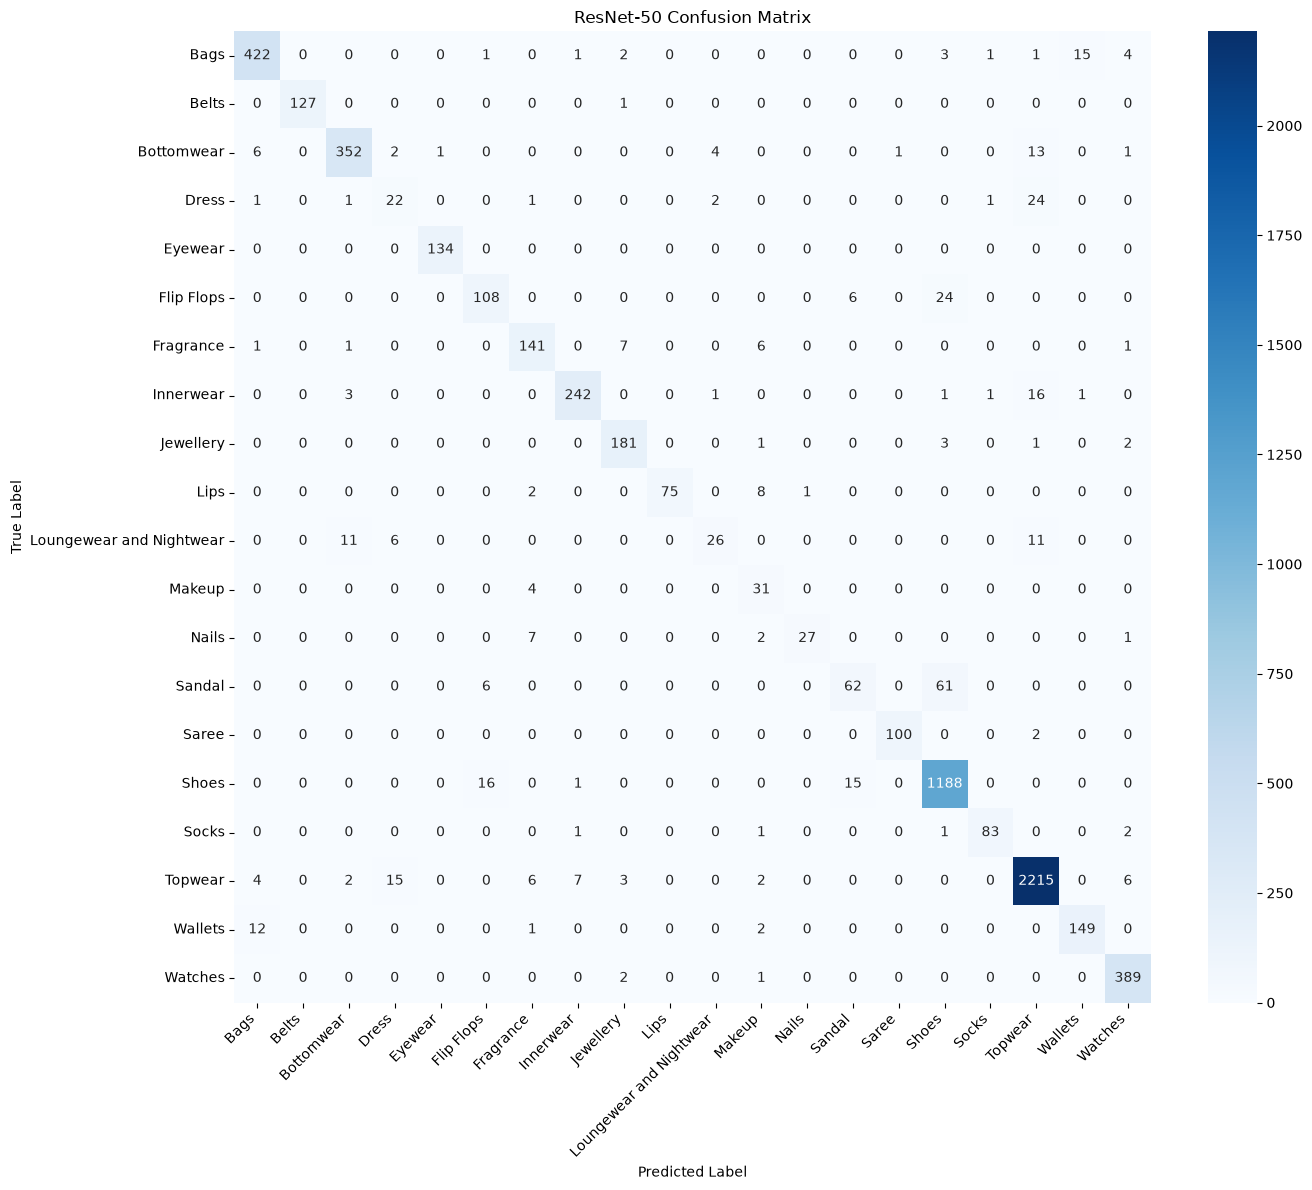

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Class names in label order
class_names = [
    name for name, label in sorted(
        label_mapping.items(),
        key=lambda x: x[1]
    )
]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet-50 Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

19. Save the Evaluation Metrics

In [31]:
from sklearn.metrics import accuracy_score, f1_score

image_metrics = {
    "test_accuracy": accuracy_score(y_true, y_pred),
    "macro_f1": f1_score(y_true, y_pred, average="macro"),
    "weighted_f1": f1_score(y_true, y_pred, average="weighted")
}

print(image_metrics)

{'test_accuracy': 0.9403932497290602, 'macro_f1': 0.8639625568902065, 'weighted_f1': 0.938385579626716}


### Evaluate Image Model

- Loaded best ResNet-50 checkpoint
- Evaluated on the held-out test set
- Test Accuracy: 94.04%
- Macro F1: 86.40%
- Weighted F1: 93.84%
- Test Loss: 0.1870
- Generated classification report
- Generated confusion matrix
- Identified major class-level confusion patterns

Major weaknesses:
- Dress
- Sandal
- Loungewear and Nightwear
- Makeup
- Flip Flops

Major confusion patterns:
- Dress → Topwear
- Sandal → Shoes
- Shoes → Flip Flops/Sandal
- Loungewear and Nightwear → Topwear/Bottomwear